# PyCBC chi-square on real H1 inputs: isolate and combine the effects

**The installed PyCBC 2.11.0 complex64 result differs by about 0.172% at the highlighted point.** Below, 16 controlled arithmetic variants separate π, phase precision, term rounding and accumulation, including their interactions. The figures attribute errors **within an explicit model**; actual compiled-PyCBC results and the model gap remain visible.

**Run:** `python -m pip install "pycbc==2.11.0" scipy matplotlib jupyterlab`, then **Restart Kernel and Run All**. Latest stable [PyPI release](https://pypi.org/project/PyCBC/2.11.0/) checked 21 September 2026. The data and shared helper are bundled or downloaded with pinned hashes. A checkout works offline.

In [1]:
import io
import hashlib
import platform
import warnings
from pathlib import Path
from urllib.request import urlopen

warnings.filterwarnings("ignore", message="Wswiglal-redir-stdio")
import numpy as np
import scipy
from scipy.fft import ifft
import matplotlib.pyplot as plt
import pycbc
from pycbc.types import Array
from pycbc.scheme import CPUScheme
from pycbc.vetoes.chisq import power_chisq_at_points_from_precomputed

print(f"PyCBC {pycbc.__version__}; NumPy {np.__version__}; SciPy {scipy.__version__}")
print(f"Python {platform.python_version()}; {platform.system()} {platform.machine()}")
assert pycbc.__version__ == '2.11.0', 'Select a kernel with the tested PyCBC 2.11.0 release.'

PyCBC 2.11.0; NumPy 2.3.5; SciPy 1.16.3
Python 3.13.9; Darwin arm64


## 1. Fixed real-search inputs

This replays saved correlation, SNR, normalization, bins and time indices from a CPU search of public **H1:LOSC-STRAIN**, using 32 compressed IMRPhenomD templates, 2048 Hz, 512-second segments, 30 Hz cutoff and 16 bins. It does not repeat strain conditioning or the search.

Capture 5 contains the largest recorded discrepancy among the first six calls (11 points); all three of its points are shown. Sample 656106 **failed the original NewSNR cut**. This selected example is not a typical-error estimate. The widest bin spans **373,308 samples**.

[Provenance and original recorded values](https://github.com/xangma/pycbc/blob/7961bd498fa8abbd6f8909cc5ebdff750cbe8fe5/examples/numerics/data/point-input-05.json) · [Original manifest](https://github.com/xangma/pycbc/blob/e8b63f56ea444dca7b5ead91ca3a34da7398e3b5/docs/_static/jax_chisq_numerics/manifest.json).

In [2]:
filename = 'point-input-05.npz'
expected_sha256 = '1b824a1b7887634d8fce7e3a7c356972f417686a2a9924b59413d262592d67ce'
data_url = ('https://raw.githubusercontent.com/xangma/pycbc/'
            '7961bd498fa8abbd6f8909cc5ebdff750cbe8fe5/examples/numerics/data/' + filename)
candidates = [Path('data') / filename, Path('examples/numerics/data') / filename]
local_file = next((p for p in candidates if p.is_file()), None)
if local_file is not None:
    payload = local_file.read_bytes()
else:
    with urlopen(data_url, timeout=60) as response:
        payload = response.read()
assert hashlib.sha256(payload).hexdigest() == expected_sha256
with np.load(io.BytesIO(payload), allow_pickle=False) as saved:
    corr = saved['corr']
    snr = saved['snr']
    norm = float(saved['norm'])
    bins = saved['bins']
    points = saved['indices']

N = len(corr)
p = len(bins) - 1
sample_rate = 2048
segment_seconds = N / sample_rate
widths = np.diff(bins)
assert corr.dtype == np.complex64 and snr.dtype == np.complex64
assert N == 2**20 and p == 16 and np.all(widths > 0)
assert np.all(np.isfinite(corr)) and np.all(points < N)
print(f'Verified {filename}: {len(payload):,} bytes')
print(f'N = {N:,}; segment = {segment_seconds:g} s; frequency spacing = {1/segment_seconds:g} Hz')
print('Selected time samples:', points.tolist())
print('Frequency samples per chi-square bin:', widths.tolist())
print(f'Widest bin: {widths.max():,} samples; {widths.max()-1:,} rotations before its final coefficient')
assert np.array_equal(points, points.astype(np.float32).astype(points.dtype))
print('Float32 index casting changes none of these captured indices.')

Verified point-input-05.npz: 8,390,014 bytes
N = 1,048,576; segment = 512 s; frequency spacing = 0.00195312 Hz
Selected time samples: [484954, 619888, 656106]
Frequency samples per chi-square bin: [9156, 4750, 5023, 5126, 4290, 4627, 4359, 4951, 6051, 6467, 7951, 9583, 12507, 17611, 33168, 373308]
Widest bin: 373,308 samples; 373,307 rotations before its final coefficient
Float32 index casting changes none of these captured indices.


## 2. Installed PyCBC and two independent references

Run both input precisions under `CPUScheme`. Separately evaluate each bin with a complex128 inverse FFT and a direct sum using modular phases; they must agree. Every comparison holds the saved SNR-power term and normalization fixed. Original search FFT backend: MKL; the stored correlation is unchanged here.

In [3]:
chisq_cpu = {}
with CPUScheme():
    for dtype in (np.complex64, np.complex128):
        value = power_chisq_at_points_from_precomputed(
            Array(corr.astype(dtype)), snr, norm, bins, points)
        chisq_cpu[np.dtype(dtype).name] = value
        print(f'{np.dtype(dtype).name} input -> {value.dtype} result: {value}')

complex64 input -> float32 result: [33.316555 36.282463 43.05497 ]
complex128 input -> float64 result: [33.32588347 36.33701184 42.98118821]


In [4]:
fft_bin_power = []
fft_power = np.zeros(len(points), dtype=np.float64)
direct_power = np.zeros_like(fft_power)
for lo, hi in zip(bins[:-1], bins[1:]):
    band = np.zeros(N, dtype=np.complex128)
    band[lo:hi] = corr[lo:hi]
    amplitudes = (N * ifft(band, workers=1))[points]
    fft_bin_power.append(np.abs(amplitudes)**2)
    fft_power += fft_bin_power[-1]

    frequencies = np.arange(lo, hi, dtype=np.int64)
    for j, point in enumerate(points):
        cycles = (frequencies * int(point)) % N
        phases = np.exp(2j * np.pi * cycles / N)
        amplitude = np.sum(corr[lo:hi] * phases, dtype=np.complex128)
        direct_power[j] += abs(amplitude)**2

# Preserve the captured complex64 SNR-power calculation in every comparison.
snr_power = (snr.conj() * snr).real
chisq_fft = (p * fft_power - snr_power) * norm**2
chisq_direct = (p * direct_power - snr_power) * norm**2
np.testing.assert_allclose(chisq_direct, chisq_fft, rtol=1e-10, atol=1e-10)
assert np.all(chisq_fft > 0)
print('FFT reference:', chisq_fft)
print('Maximum direct-sum / FFT relative difference:',
      np.max(np.abs(chisq_direct - chisq_fft) / chisq_fft))
reference_cumulative = np.cumsum(np.array(fft_bin_power).T, axis=1)

FFT reference: [33.32594174 36.33709527 42.98097342]
Maximum direct-sum / FFT relative difference: 4.2642019923476617e-16


## 3. Four switches; all 16 combinations

Each switch introduces one issue into an otherwise double-precision, full-π calculation:

| Switch | What changes |
|---|---|
| π | Use `3.141592653` |
| Phase | Store initial/step phases and update the recurrence in float32 |
| Terms | Round each operation of the three-product complex multiply to float32 |
| Sums / powers | Cast terms to float32, add sequentially, form powers and sum across bins in float32 |

The final χ² expression is always evaluated in float64 in the model. This keeps wrapper rounding outside the four switches. **Index casting has zero effect on these saved indices**, verified above; its separate boundary test is in the [synthetic notebook](cpu_chisq_precision.ipynb).

The [99-line shared model](https://github.com/xangma/pycbc/blob/4e06fff52a7181f9cb3e8ffffe5b7a3866827a11/examples/numerics/chisq_error_controls.py) is bundled or downloaded with a pinned hash. It implements explicit arithmetic controls in NumPy; it is **not a modified PyCBC binary**. Compiler contraction and library arithmetic can differ. No JAX or new compiled extension is needed.

In [5]:
from pathlib import Path
from urllib.request import urlopen
import hashlib
import matplotlib.pyplot as plt

# A small, inspectable NumPy model shared by both notebooks; no compiler needed.
helper_name = 'chisq_error_controls.py'
helper_commit = '4e06fff52a7181f9cb3e8ffffe5b7a3866827a11'
helper_sha = 'e582bdbca7184ac59fe96d4058c03d59a4123056a34ce705a397c0a0a1a98954'
local = next((p for p in [Path(helper_name), Path('examples/numerics') / helper_name]
              if p.is_file()), None)
if local is not None:
    source = local.read_bytes()
else:
    url = f'https://raw.githubusercontent.com/xangma/pycbc/{helper_commit}/examples/numerics/{helper_name}'
    with urlopen(url, timeout=60) as response:
        source = response.read()
assert hashlib.sha256(source).hexdigest() == helper_sha
exec(compile(source, helper_name, 'exec'))
plt.rcParams.update({'font.size': 10, 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.grid': True,
                     'grid.alpha': 0.18, 'lines.linewidth': 1.7})


In [6]:
model_power = controlled_powers(corr, points, bins)
model_chisq = {mask: (p*power[:, -1]-snr_power)*norm**2
               for mask, power in model_power.items()}
np.testing.assert_allclose(model_chisq[0], chisq_fft, rtol=1e-9, atol=1e-9)
# Truncated pi with otherwise double arithmetic also reproduces the compiled
# complex128 control closely; the float32 model is not a bitwise CPU emulator.
np.testing.assert_allclose(model_chisq[1], chisq_cpu['complex128'], rtol=1e-9, atol=1e-9)
assert all(np.all(np.isfinite(value)) for value in model_power.values())
# Fixed denominator: FINAL reference chi-square, not a partial chi-square.
errors = {mask: 100*p*norm**2*(power-reference_cumulative)/chisq_fft[:, None]
          for mask, power in model_power.items()}
effects, interactions = decompose(errors)
highlight = int(np.flatnonzero(points == 656106)[0])
actual_error = {name: 100*(value/chisq_fft-1) for name, value in chisq_cpu.items()}
model_gap = 100*(model_chisq[15]-chisq_cpu['complex64'])/chisq_fft
print('All entries below are signed errors in %, relative to the independent FFT.')
print(f"{'sample':>8} {'CPU c64':>12} {'CPU c128':>12} {'model all':>12} {'model good':>12} {'model−CPU':>12}")
for j, point in enumerate(points):
    print(f"{point:8d} {actual_error['complex64'][j]:12.6g} {actual_error['complex128'][j]:12.6g} "
          f"{errors[15][j,-1]:12.6g} {errors[0][j,-1]:12.3g} {model_gap[j]:12.3g}")
print(f'\nModel attribution at sample {points[highlight]} (percentage points):')
for bit, label in FACTORS.items():
    print(f'{label:25s} {effects[bit][highlight,-1]:+.8f}')
print(f'{"All interactions":25s} {interactions[highlight,-1]:+.8f}')
print(f'{"Baseline residual":25s} {effects[0][highlight,-1]:+.3g}')
print(f'{"Combined error":25s} {errors[15][highlight,-1]:+.8f}')


All entries below are signed errors in %, relative to the independent FFT.
  sample      CPU c64     CPU c128    model all   model good    model−CPU
  484954   -0.0281664 -0.000174854   -0.0290199    -1.67e-10    -0.000854
  619888    -0.150348 -0.000229605    -0.149634     1.26e-10     0.000714
  656106     0.172161  0.000499742     0.172096     4.85e-11    -6.49e-05

Model attribution at sample 656106 (percentage points):
Truncated π               +0.00049974
Float32 phase             +0.17355414
Float32 terms             -0.00000119
Float32 sums / powers     -0.00062063
All interactions          -0.00133621
Baseline residual         +4.85e-11
Combined error            +0.17209585


## 4. Individual effects and their interaction

Each coloured line is **issue-only error minus the all-improved baseline**. The combined model satisfies:

**combined = baseline + four individual effects + interactions**.

All 16 variants are used to calculate the interaction terms; the identity is checked at every bin. These are signed, input-dependent effects, not universal percentage shares. The panels use a symmetric log scale so small signed effects remain visible. The x-axis adds complete bins; the y-axis is each cumulative power difference expressed as a percentage of **final reference χ²**, not a partial χ² statistic.

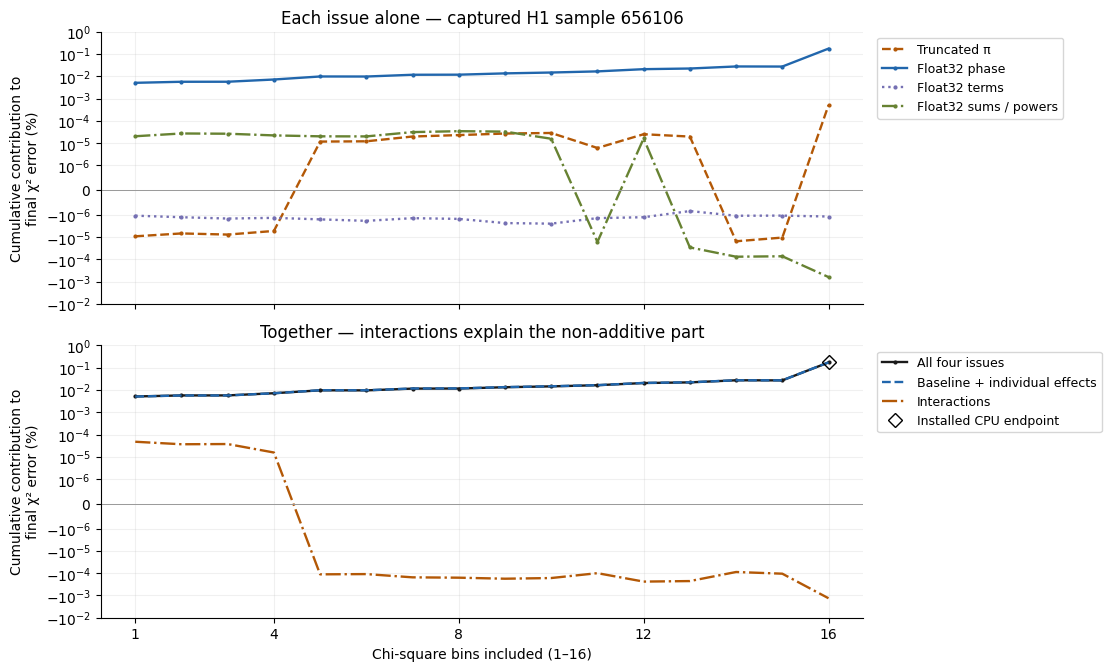

In [7]:
x = np.arange(1, p+1)
fig, axes = plt.subplots(2, 1, figsize=(11, 6.6), sharex=True, layout='constrained')
for bit, label in FACTORS.items():
    axes[0].plot(x, effects[bit][highlight], label=label,
                 color=COLORS[bit], ls=STYLES[bit], marker='.', ms=4)
axes[0].set_title(f'Each issue alone — captured H1 sample {points[highlight]}')
axes[0].legend(fontsize=9, loc='upper left', bbox_to_anchor=(1.01, 1))
additive = effects[0] + sum(effects[bit] for bit in FACTORS)
axes[1].plot(x, errors[15][highlight], color='0.1', label='All four issues', marker='.', ms=4)
axes[1].plot(x, additive[highlight], color='#2166ac', ls='--', label='Baseline + individual effects')
axes[1].plot(x, interactions[highlight], color='#b35806', ls='-.', label='Interactions')
axes[1].plot(p, actual_error['complex64'][highlight], 'D', mfc='none', mec='black', ms=7,
             label='Installed CPU endpoint')
axes[1].set_title('Together — interactions explain the non-additive part')
axes[1].set(xlabel='Chi-square bins included (1–16)', xticks=[1,4,8,12,16])
axes[1].legend(fontsize=9, loc='upper left', bbox_to_anchor=(1.01, 1))
for ax in axes:
    ax.set_yscale('symlog', linthresh=1e-6)
    ax.set_ylim(-0.01, 1)
    ax.set_ylabel('Cumulative contribution to\nfinal χ² error (%)')
    ax.axhline(0, color='0.6', lw=0.7)
plt.show()


**Readout:** phase precision dominates the model error here; π, term rounding, and accumulation produce smaller effects, with nonzero interactions. The all-improved model agrees closely with both references. Its float32 counterpart differs from compiled PyCBC by the explicitly reported model gap, so these curves are **not an exact allocation of the executable's error**.

No runtime, sensitivity, ranking or false-alarm effect is established. These controls guide a future compiled-kernel patch and its regression tests.

Sources: [PyCBC 2.11.0 CPU code](https://github.com/gwastro/pycbc/blob/v2.11.0/pycbc/vetoes/chisq_cpu.pyx) · [Full report](https://github.com/xangma/pycbc/blob/e8b63f56ea444dca7b5ead91ca3a34da7398e3b5/docs/jax_chisq_numerics.rst).